<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U3-T1-V2.2-Recomendação colaborativa baseada em memória</b></h2>


---

# Exemplo 01 - Recomendação User x User

**Como funciona a recomendação colaborativa?**

A ideia básica da recomendação colaborativa é considerar a avaliação de outros usuários similares (*user-user*) ou a avaliação de itens similares (*item-item*) para estimar a avaliação de itens não vistos para um usuário.


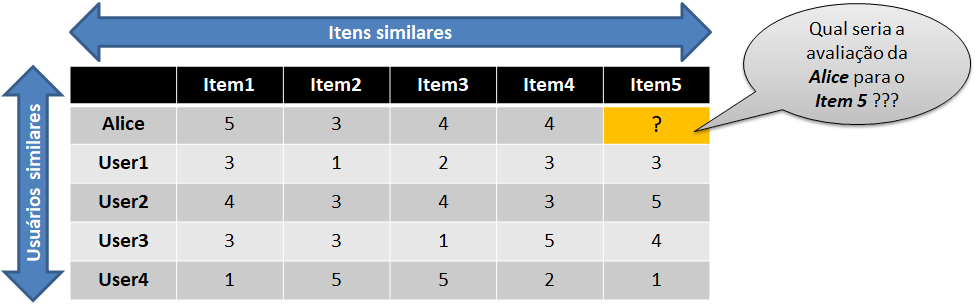

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

In [16]:
vratings = [ (0,0,5), (0,1,3), (0,2,4), (0,3,4),
           (1,0,3), (1,1,1), (1,2,2), (1,3,3), (1,4,3),
           (2,0,4), (2,1,3), (2,2,4), (2,3,3), (2,4,5),
           (3,0,3), (3,1,3), (3,2,1), (3,3,5), (3,4,4),
           (4,0,1), (4,1,5), (4,2,5), (4,3,2), (4,4,1) ]

ratings = pd.DataFrame(vratings, columns=['user','item','rating'])
m_ratings = ratings.pivot_table(values='rating', index='user', columns='item')
m_ratings

item,0,1,2,3,4
user,,,,,
0,5.0,3.0,4.0,4.0,NaN
1,3.0,1.0,2.0,3.0,3.0
2,4.0,3.0,4.0,3.0,5.0
3,3.0,3.0,1.0,5.0,4.0
4,1.0,5.0,5.0,2.0,1.0


## Similaridade entre os usuários

A similaridade entre dois usuários pode ser medida utilizando-se diversas métricas que consideram o quanto as avaliações de cada um deles são semelhantes

### **Similaridade do cosseno**

In [17]:
sims = pd.DataFrame(cosine_similarity(m_ratings.fillna(0),m_ratings.fillna(0)))
print('User x User - Cosseno\n')
sims

User x User - Cosseno



,0,1,2,3,4
0,1.000000,0.826869,0.810163,0.762770,0.789542
1,0.826869,1.000000,0.959383,0.935693,0.637815
2,0.810163,0.959383,1.000000,0.894427,0.771517
3,0.762770,0.935693,0.894427,1.000000,0.638311
4,0.789542,0.637815,0.771517,0.638311,1.000000


### **Correlação de pearson**

In [18]:
sims = m_ratings.T.corr(method='pearson')
print('User x User - Pearson\n')
sims

User x User - Pearson



user,0,1,2,3,4
user,,,,,
0,1.000000,0.852803,0.707107,0.000000,-0.792118
1,0.852803,1.000000,0.467707,0.489956,-0.900149
2,0.707107,0.467707,1.000000,-0.161165,-0.466569
3,0.000000,0.489956,-0.161165,1.000000,-0.641503
4,-0.792118,-0.900149,-0.466569,-0.641503,1.000000


Usuários mais similares

In [19]:
sims[ sims > 0 ][ sims != 1 ].fillna('')

user,0,1,2,3,4
user,,,,,
0,,0.852803,0.707107,,
1,0.852803,,0.467707,0.489956,
2,0.707107,0.467707,,,
3,,0.489956,,,
4,,,,,


## Estimando as avaliações

### Avaliação média de cada usuário

In [20]:
users = m_ratings.index
items = m_ratings.columns

m_ratings

item,0,1,2,3,4
user,,,,,
0,5.0,3.0,4.0,4.0,NaN
1,3.0,1.0,2.0,3.0,3.0
2,4.0,3.0,4.0,3.0,5.0
3,3.0,3.0,1.0,5.0,4.0
4,1.0,5.0,5.0,2.0,1.0


In [21]:
avg_u = m_ratings.mean(axis=1)
pd.DataFrame(avg_u)

,0
user,
0,4.0
1,2.4
2,3.8
3,3.2
4,2.8


### Qual a avaliação da Alice (user 0) para o item5 (índice 4)

In [22]:
m_ratings

item,0,1,2,3,4
user,,,,,
0,5.0,3.0,4.0,4.0,NaN
1,3.0,1.0,2.0,3.0,3.0
2,4.0,3.0,4.0,3.0,5.0
3,3.0,3.0,1.0,5.0,4.0
4,1.0,5.0,5.0,2.0,1.0


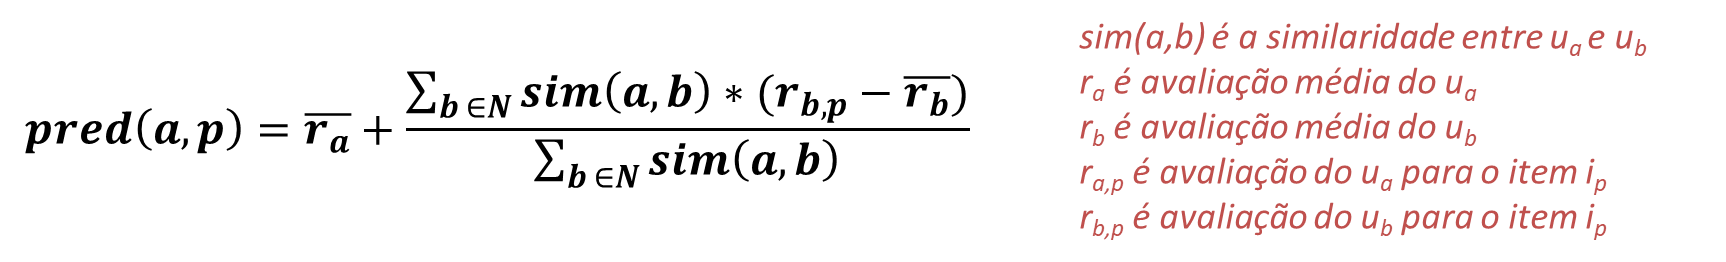

In [23]:
soma = 0.0
aux = 0.0
for i, sim in enumerate(sims[0][1:]):
    if sim > 0:
        print(f'{sim:.2f} * ({m_ratings.iloc[i+1][4]:.2f} - {m_ratings.iloc[i+1].mean():.2f} ) = {( m_ratings.iloc[i+1][4] - m_ratings.iloc[i+1].mean()) * sim:.2f}')
        aux += ( m_ratings.iloc[i+1][4] - m_ratings.iloc[i+1].mean()) * sim
        soma += sim

print(f'{aux:.2f} / {soma:.2f} = {aux / soma:.2f}\n')
print('Avaliação da Alice para o Item 5')
print(f'{avg_u[0]} + {aux / soma:.2f} = {avg_u[0] + (aux/soma):.2f}')


0.85 * (3.00 - 2.40 ) = 0.51
0.71 * (5.00 - 3.80 ) = 0.85
1.36 / 1.56 = 0.87

Avaliação da Alice para o Item 5
4.0 + 0.87 = 4.87


Função **`get_prediction_users()`**

In [24]:
def get_prediction_users(users, items, sim='pearson', knn=10):
    preds = []

    m_ratings_T = m_ratings.T
    avg_i = m_ratings.mean(axis=0)
    avg_u = m_ratings.mean(axis=1)

    if sim == 'pearson':
        sims = m_ratings_T.corr(method='pearson')
    elif sim == 'cosine':
        sims = pd.DataFrame(cosine_similarity(m_ratings.fillna(0),m_ratings.fillna(0)))
    else:
        raise Exception('Similaridade deve ser "pearson" ou "cosine"')

    for user in users:
        # Seleciona os k vizinhos mais similares
        vizinhos = sims[user].drop(user).sort_values(ascending=False).index[:knn]
        for item in items:

            # Filtra as similaridades dos vizinhos que são positivas
            vsims = sims.loc[user][vizinhos]
            vsims = vsims[ vsims > 0]

            # Filtra os ratings não nulos dos vizinhos para o item
            vrats = m_ratings.loc[vsims.index][item]
            hasRated = ~np.isnan(vrats)
            vrats = vrats[hasRated]

            # Filtra as similaridades correspondentes aos ratings não nulos
            vsims = vsims.loc[vrats.index]
            soma = vsims.sum()

            if soma > 0.0:
                pred_rating = (avg_u[user] + (np.dot(vsims, vrats - avg_u[vsims.index]) / soma))
            else:
                pred_rating = np.mean( np.array([ avg_i[item], avg_u[user] ]) )

            preds.append([ user, item, pred_rating ])

    preds_df = pd.DataFrame(preds, columns=['user','item','pred_rating'])
    pivot = preds_df.pivot_table(values='pred_rating', index='user', columns='item')

    return preds, preds_df, pivot

In [25]:
preds, preds_df, pivot = get_prediction_users([0], [4], sim='pearson')
pivot

item,4
user,
0,4.87198


In [26]:
preds, preds_df, pivot = get_prediction_users(users, items, sim='pearson')
pivot

item,0,1,2,3,4
user,,,,,
0,4.418680,2.871980,3.871980,3.965380,4.871980
1,2.868583,1.668166,1.856294,2.680455,3.395354
2,4.640755,2.640755,3.640755,4.038867,4.400000
3,3.800000,1.800000,2.800000,3.800000,3.800000
4,3.000000,2.900000,3.000000,3.100000,3.025000


In [27]:
preds, preds_df, pivot = get_prediction_users(users, items, sim='cosine')
pivot

item,0,1,2,3,4
user,,,,,
0,3.712927,3.930610,3.965568,4.184785,4.206110
1,2.305809,2.287396,2.262057,2.520987,2.696794
2,3.747075,3.615209,3.609589,4.256525,3.762840
3,3.309591,2.771677,3.574131,2.994264,3.396793
4,3.222557,1.944448,2.269507,3.122304,3.688416


# Exemplo 02 - Recomendação Item x Item

## Similaridade entre os itens

Além da similaridade do cosseno e do coeficiente de pearson, será utilizada uma **medida do cosseno ajustada** pela avaliação média do usuário

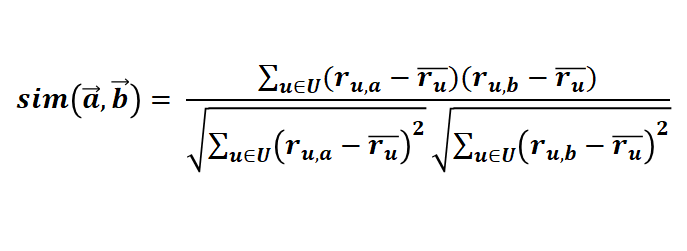

Avaliações

In [27]:
m_ratings.T

user,0,1,2,3,4
item,,,,,
0,5.0,3.0,4.0,3.0,1.0
1,3.0,1.0,3.0,3.0,5.0
2,4.0,2.0,4.0,1.0,5.0
3,4.0,3.0,3.0,5.0,2.0
4,NaN,3.0,5.0,4.0,1.0


Avaliações ajustadas

In [28]:
avg_u

,0
user,
0,4.0
1,2.4
2,3.8
3,3.2
4,2.8


In [29]:
avg_u.reset_index().drop('user',axis=1).T

,0,1,2,3,4
0,4.0,2.4,3.8,3.2,2.8


Computar a avaliação menos a avaliação média de cada usuário

In [30]:
m_ratings_T = m_ratings.T
adj_m_ratings = m_ratings_T - avg_u
adj_m_ratings = adj_m_ratings.fillna(0)
adj_m_ratings


user,0,1,2,3,4
item,,,,,
0,1.0,0.6,0.2,-0.2,-1.8
1,-1.0,-1.4,-0.8,-0.2,2.2
2,0.0,-0.4,0.2,-2.2,2.2
3,0.0,0.6,-0.8,1.8,-0.8
4,0.0,0.6,1.2,0.8,-1.8


Cálculo da similaridade ajustada

In [31]:
sims = pd.DataFrame(cosine_similarity(adj_m_ratings,adj_m_ratings))
print('Item x Item - Cosseno ajustado\n')
sims

Item x Item - Cosseno ajustado



,0,1,2,3,4
0,1.000000,-0.939725,-0.547068,0.267841,0.713758
1,-0.939725,1.000000,0.620543,-0.360645,-0.853001
2,-0.547068,0.620543,1.000000,-0.881380,-0.763560
3,0.267841,-0.360645,-0.881380,1.000000,0.433063
4,0.713758,-0.853001,-0.763560,0.433063,1.000000


## Estimando as avaliações

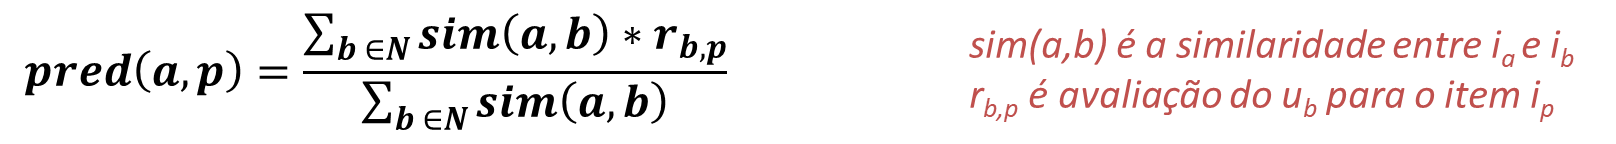

In [32]:
soma = 0.0
aux = 0.0
for i, sim in enumerate(sims[4][0:4]):
    if sim > 0:
        print(f'{sim:.2f} * {m_ratings.T.iloc[i][0]:.2f} = {m_ratings.T.iloc[i][0] * sim:.2f}')
        aux += ( m_ratings.T.iloc[i][0]) * sim
        soma += sim

print('\nAvaliação da Alice para o Item 5')
print(f'{aux:.2f} / {soma:.2f} = {aux / soma:.2f}')


0.71 * 5.00 = 3.57
0.43 * 4.00 = 1.73

Avaliação da Alice para o Item 5
5.30 / 1.15 = 4.62


Função **`get_prediction_items()`**

In [33]:
def get_prediction_items(users, items, sim='pearson', knn=10):
    preds = []

    m_ratings_T = m_ratings.T
    avg_i = m_ratings.mean(axis=0)
    avg_u = m_ratings.mean(axis=1)
    adj_m_ratings = m_ratings_T - avg_u
    adj_m_ratings = adj_m_ratings.fillna(0)

    if sim == 'pearson':
        sims = m_ratings_T.corr(method='pearson')
    elif sim == 'cosine':
        sims = pd.DataFrame(cosine_similarity(m_ratings.fillna(0),m_ratings.fillna(0)))
    elif sim == 'adj_cosine':
        sims = pd.DataFrame(cosine_similarity(adj_m_ratings, adj_m_ratings))
    else:
        raise Exception('Similaridade deve ser "pearson" ou "cosine"')

    for item in items:
        # Seleciona os k vizinhos mais similares
        vizinhos = sims[item].drop(item).sort_values(ascending=False).index[:knn]
        for user in users:
            # Filtra as similaridades dos itens vizinhos que são positivas
            vsims = sims.loc[item][vizinhos]
            vsims = vsims[ vsims > 0]
            # Filtra os ratings não nulos dos vizinhos para o usuário
            vrats = m_ratings_T.loc[vsims.index][user]
            hasRated = ~np.isnan(vrats)
            vrats = vrats[hasRated]
            # Filtra as similaridades correspondentes aos ratings não nulos
            vsims = vsims.loc[vrats.index]
            soma = vsims.sum()
            if soma > 0.0:
                pred_rating = (np.dot(vsims, vrats) / soma)
            else:
                pred_rating = np.mean( np.array([ avg_i[item], avg_u[user] ]) )

            preds.append([ user, item, pred_rating ])

    preds_df = pd.DataFrame(preds, columns=['user','item','pred_rating'])
    pivot = preds_df.pivot_table(values='pred_rating', index='user', columns='item')

    return preds, preds_df, pivot

In [34]:
preds, preds_df, pivot = get_prediction_items([0],[4],sim='adj_cosine')
pivot

item,4
user,
0,4.62238


### Estimando usando pearson

In [35]:
preds, preds_df, pivot = get_prediction_items(users, items,sim='pearson')
pivot

item,0,1,2,3,4
user,,,,,
0,3.4533,4.471041,4.203777,3.0,3.625
1,1.4533,2.741665,2.203777,1.0,2.825
2,3.4533,3.729376,3.601888,3.0,3.525
3,2.0934,3.024578,3.000000,3.0,3.225
4,5.0000,2.303965,2.592447,5.0,3.025


In [ ]:
m_ratings

### Estimando usando cosseno

In [36]:
preds, preds_df, pivot = get_prediction_items(users, items, sim='cosine')
pivot

item,0,1,2,3,4
user,,,,,
0,3.655443,4.303779,3.943986,3.933309,4.053478
1,2.227458,2.714449,2.441487,2.144029,2.278458
2,3.749134,3.911340,3.684967,3.907965,3.550214
3,3.217837,3.175737,3.745271,2.643927,2.906100
4,3.292289,2.420705,2.377376,3.265560,3.211924


### Estimando usando cosseno ajustado pela avaliação média do usuário

In [37]:
preds, preds_df, pivot = get_prediction_items(users, items, sim='adj_cosine')
pivot

item,0,1,2,3,4
user,,,,,
0,4.000000,4.0,3.0,5.000000,4.622380
1,3.000000,2.0,1.0,3.000000,3.000000
2,4.454276,4.0,3.0,4.617863,3.622380
3,4.272862,1.0,3.0,3.617863,3.755241
4,1.272862,5.0,5.0,1.000000,1.377620


# Exemplo 03 - Quem gostou deste filme, vai gostar de...

## Biblioteca  ***Surprise***

Surprise é um scikit-learn em Python para construir e analisar sistemas de recomendação que lidam com dados de classificação explícitos.

https://surpriselib.com/

In [ ]:
# O ambiente do Google Colab tem a versão mais recente do numpy
# A biblioteca Surprise foi compilada com versões mais antigas
# É necessário instalar esta versão para rodar o Suprise

try:
    !pip uninstall -yq numpy
    !pip install -q numpy==1.26.4
finally:
    import os
    os.kill(os.getpid(), 9)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you ha

In [1]:
!pip install -q scikit-surprise

In [2]:
from surprise import KNNBaseline
from surprise import Dataset
from surprise import Reader
import pandas as pd

## Carregar os arquivos

### Carregar o arquivo de filmes

In [3]:
movies = pd.read_csv('https://drive.google.com/uc?export=download&id=1yjGdaAJ5-YgIUx_1mLTcPqiZ8OI9TeqH', encoding='latin-1', low_memory=False)
movies['tags'] = movies['tags'].apply(lambda x: '' if isinstance(x,float) else x)
movies.set_index('movieId', inplace=True)
movies.head()

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.920930,3.894473
2,Jumanji,Adventure|Children|Fantasy,fantasy magic_board_game game robin_williams,4,110,3.431818,3.419009
3,Grumpier Old Men,Comedy|Romance,old moldy,2,52,3.259615,3.260033
4,Waiting to Exhale,Comedy|Drama|Romance,,0,7,2.357143,2.866377
5,Father of the Bride Part II,Comedy,pregnancy remake,2,49,3.071429,3.101070


### Carregar o arquivo de avaliações

In [4]:
ratings = pd.read_csv('https://drive.google.com/uc?export=download&id=1yCT7ximzeYFYHWAbJz3DO8_GL5raID74', encoding='latin-1', low_memory=False)
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### Formatar arquivos para a Surprise

In [5]:
reader = Reader(rating_scale=(0, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# arquivos de treino e teste
trainset = data.build_full_trainset()
testset = trainset.build_testset()

# arquivo de dados ausentes
ausentes = trainset.build_anti_testset()

## Recomendações para um filme específico

### Recuperar os filmes vizinhos (Item-Item)

Computar a similaridade entre os itens

In [6]:
sim_options = {"name": "pearson_baseline", "user_based": False}  # item - item
modelo_itens = KNNBaseline(sim_options=sim_options)
modelo_itens.fit(trainset)


Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


Função para retornar os itens vizinhos

In [7]:
movies[ movies.index.isin([1]) ]

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.92093,3.894473


In [8]:
def get_itens_vizinhos(movieId, k=10):
    iid = trainset.to_inner_iid(movieId)
    aux = modelo_itens.get_neighbors(iid,k)
    return [modelo_itens.trainset.to_raw_iid(inner_id) for inner_id in aux]

get_itens_vizinhos(1)


[3114, 588, 8961, 6377, 1270, 78499, 34, 1097, 2716, 4886]

### Função para retornar as recomendações

In [9]:
def get_movie_recommendations(movie=None, k=3):

    # Seleciona o subset de filmes vizinhos
    aux = get_itens_vizinhos(movie, k)
    vizinhos = pd.DataFrame(enumerate(aux), columns=['rank','movieId']).set_index('movieId')
    return movies.loc[aux][['title','genres','imdb_score']].join(vizinhos, on='movieId').sort_values(by=['rank'])

get_movie_recommendations(movie=1)

,title,genres,imdb_score,rank
movieId,,,,
3114,Toy Story 2,Adventure|Animation|Children|Comedy|Fantasy,3.810019,0
588,Aladdin,Adventure|Animation|Children|Comedy|Musical,3.767511,1
8961,"Incredibles, The",Action|Adventure|Animation|Children|Comedy,3.797478,2


In [10]:
movies[ movies.index.isin([858]) ]

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
858,"Godfather, The",Crime|Drama,mafia,1,192,4.289062,4.243095


In [11]:
get_movie_recommendations(movie=858)

,title,genres,imdb_score,rank
movieId,,,,
1221,"Godfather: Part II, The",Crime|Drama,4.194652,0
1213,Goodfellas,Crime|Drama,4.184163,1
296,Pulp Fiction,Comedy|Crime|Drama|Thriller,4.170449,2
